#### The code below is a function that compares two Random Forest models with different feature sets against three baselines.
Run it first before doing the other things

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ==========================================
# 1. DATA LOADING & BASELINE PREP
# ==========================================
match   = pd.read_csv("../data/gold_match_with_league_standings.csv")
tickets = pd.read_csv("../data/gold_match_tickets.csv")
context = pd.read_csv("../data/gold_match_context.csv")

match = match[match["is_home_match"] == True]
df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

# Handle potential suffix issues
if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

df["match_date"] = pd.to_datetime(df["match_date"])
df = df.sort_values("match_date").reset_index(drop=True)

# --- REQUIRED BASELINE CALCULATIONS (The function needs these) ---

# 1. Opponent Average Baseline
df["opponent_avg"] = df.groupby("away_team")["tickets_scanned"].transform(lambda x: x.shift().expanding().mean())
df["season_expanding_avg"] = df["tickets_scanned"].shift().expanding().mean()
df["opponent_avg"] = df["opponent_avg"].fillna(df["season_expanding_avg"])

# 2. Same Fixture Baseline
def get_last_fixture(row, dataframe):
    past = dataframe[(dataframe["away_team"] == row["away_team"]) & (dataframe["match_date"] < row["match_date"])]
    if not past.empty:
        return past.iloc[-1]["tickets_scanned"]
    return np.nan

df["same_fixture_baseline"] = df.apply(lambda r: get_last_fixture(r, df), axis=1)
df["same_fixture_baseline"] = df["same_fixture_baseline"].fillna(df["season_expanding_avg"])

# Cleanup Helper
def parse_result(value):
    if pd.isna(value): return None
    if value.startswith("W"): return 3
    elif value.startswith("D"): return 1
    elif value.startswith("L"): return 0
    return None
df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)

# ==========================================
# 2. FUNCTION DEFINITION
# ==========================================
def compare_feature_sets(df, features_1, features_2, name_1="Model 1", name_2="Model 2"):
    # 1. PREP & SORT
    if "match_date" in df.columns:
        df = df.sort_values("match_date").reset_index(drop=True)
        
    seasons = sorted(df["season"].unique())
    season_results = []
    
    required_cols = list(set(features_1 + features_2 + ["tickets_scanned", "season", "opponent_avg", "same_fixture_baseline"]))
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    df_clean = df.dropna(subset=required_cols).copy().reset_index(drop=True)

    print(f"{'='*80}")
    print(f"FEATURE SET COMPARISON: {name_1} vs {name_2}")
    print(f"{'='*80}")

    # 2. WALK-FORWARD VALIDATION PER SEASON
    for test_season in seasons:
        df_prior = df_clean[df_clean["season"] != test_season].copy()
        df_target = df_clean[df_clean["season"] == test_season].copy().reset_index(drop=True)

        if len(df_prior) < 10 or len(df_target) < 5:
            continue

        y_test_actuals, pred_m1_list, pred_m2_list = [], [], []
        pred_season_list, pred_opp_list, pred_fix_list = [], [], []

        for i in range(len(df_target)):
            test_match = df_target.iloc[[i]].copy()
            train_matches = pd.concat([df_prior, df_target.iloc[:i]]).copy()

            y_train = train_matches["tickets_scanned"]
            y_test_val = test_match["tickets_scanned"].values[0]

            # Model 1 Prep
            cat_1 = train_matches[features_1].select_dtypes(exclude=[np.number]).columns.tolist()
            X_tr_1 = pd.get_dummies(train_matches[features_1], columns=cat_1, drop_first=True)
            X_te_1 = pd.get_dummies(test_match[features_1], columns=cat_1, drop_first=True).reindex(columns=X_tr_1.columns, fill_value=0)

            # Model 2 Prep
            cat_2 = train_matches[features_2].select_dtypes(exclude=[np.number]).columns.tolist()
            X_tr_2 = pd.get_dummies(train_matches[features_2], columns=cat_2, drop_first=True)
            X_te_2 = pd.get_dummies(test_match[features_2], columns=cat_2, drop_first=True).reindex(columns=X_tr_2.columns, fill_value=0)

            rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
            
            rf.fit(X_tr_1, y_train)
            pred_m1_list.append(rf.predict(X_te_1)[0])
            
            rf.fit(X_tr_2, y_train)
            pred_m2_list.append(rf.predict(X_te_2)[0])

            y_test_actuals.append(y_test_val)
            pred_season_list.append(train_matches["tickets_scanned"].mean())
            pred_opp_list.append(test_match["opponent_avg"].values[0])
            pred_fix_list.append(test_match["same_fixture_baseline"].values[0])

        if not y_test_actuals: continue

        y_test = np.array(y_test_actuals)
        mae_m1 = mean_absolute_error(y_test, pred_m1_list)
        mae_m2 = mean_absolute_error(y_test, pred_m2_list)
        
        # Store for DF
        season_results.append({
            "season": test_season,
            "Baseline: Season Avg": mean_absolute_error(y_test, pred_season_list),
            "Baseline: Opponent Avg": mean_absolute_error(y_test, pred_opp_list),
            "Baseline: Same Fixture": mean_absolute_error(y_test, pred_fix_list),
            name_1: mae_m1,
            name_2: mae_m2
        })
        print(f"✓ Season {test_season} processed.")

    # 3. AGGREGATE DATA
    results_df = pd.DataFrame(season_results).set_index("season")
    latest_season_name = results_df.index[-1]
    
    # Calculate means and append as a new row
    overall_means = results_df.mean()
    results_df.loc["AVERAGE"] = overall_means

    # 4. FINAL PRINTED SUMMARY (Latest vs Overall)
    print(f"\n{'='*60}")
    print(f"{'FINAL PERFORMANCE SUMMARY':^60}")
    print(f"{'='*60}")
    print(f"{'Metric':<25} | {'Latest ('+str(latest_season_name)+')':<15} | {'Overall Avg':<12}")
    print("-" * 60)
    for col in results_df.columns:
        latest_val = results_df.loc[latest_season_name, col]
        avg_val = results_df.loc["AVERAGE", col]
        print(f"{col:<25} | {latest_val:<15.0f} | {avg_val:<12.0f}")
    print(f"{'='*60}\n")

    # 5. PLOTTING
    cols = ["Baseline: Season Avg", "Baseline: Opponent Avg", "Baseline: Same Fixture", name_1, name_2]
    colors = ["#d9d9d9", "#bdbdbd", "#969696", "#2ca02c", "#1f77b4"]
    
    x = np.arange(len(results_df))
    width = 0.15
    fig, ax = plt.subplots(figsize=(14, 7))
    offsets = [-2*width, -width, 0, width, 2*width]

    for i, (col, color) in enumerate(zip(cols, colors)):
        rects = ax.bar(x + offsets[i], results_df[col], width=width, label=col, color=color)
        
        # Add text labels for the LATEST season and the AVERAGE group
        # This makes the "numbers you care most about" visible directly on the graph
        for j, rect in enumerate(rects):
            row_name = results_df.index[j]
            if row_name == latest_season_name or row_name == "AVERAGE":
                height = rect.get_height()
                ax.annotate(f'{height:.0f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),  # 3 points vertical offset
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(results_df.index)
    
    # Styling for clarity
    labels = ax.get_xticklabels()
    for lbl in labels:
        if lbl.get_text() == "AVERAGE":
            lbl.set_weight("bold")
            lbl.set_color("red")
        if lbl.get_text() == str(latest_season_name):
            lbl.set_weight("bold")
            lbl.set_color("black")

    ax.set_ylabel("Mean Absolute Error (MAE)")
    ax.set_title(f"Model Performance: {name_1} vs {name_2}\n(Numbers shown for Latest Season and Global Average)")
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    return results_df

#### 1. ENGINEER FEATURES

In [28]:
df = df.sort_values("match_date").reset_index(drop=True)

# --- 1. BASE NUMERICS & FIXING MISSING COLUMNS ---
df["matchday"] = pd.to_numeric(df["matchday"], errors="coerce")
df["is_weekend"] = pd.to_numeric(df["is_weekend"], errors="coerce")
df["academic_week"] = pd.to_numeric(df["academic_week"], errors="coerce")

if "tickets_trib1" in df.columns:
    df["tickets_trib1"] = pd.to_numeric(df["tickets_trib1"], errors="coerce")
else:
    df["tickets_trib1"] = np.nan

if "tickets_sold_total" in df.columns:
    df["tickets_sold_total"] = pd.to_numeric(df["tickets_sold_total"], errors="coerce")
else:
    df["tickets_sold_total"] = np.nan

# --- 2. CATEGORICALS ---
df["school_holiday_name"] = df["school_holiday_name"].fillna("None").astype(str)
df["is_public_holiday"] = df["is_public_holiday"].fillna("False").astype(str)
df["has_promotion"] = df["has_promotion"].fillna("False").astype(str)

if "stage" not in df.columns:
    df["stage"] = "None"
else:
    df["stage"] = df["stage"].fillna("None").astype(str)

# --- 3. ROLLING & EXPANDING AVERAGES ---
df["last_home_attendance"] = df["tickets_scanned"].shift(1)
df["rolling_avg_3"] = df["tickets_scanned"].shift(1).rolling(window=3).mean()
df["rolling_avg_2"] = df["tickets_scanned"].shift(1).rolling(window=2).mean()
df["rolling_avg_1"] = df["tickets_scanned"].shift(1).rolling(window=1).mean()

df["season_expanding_avg"] = df["tickets_scanned"].shift(1).expanding().mean()

# Opponent Baseline
df["opponent_avg"] = df.groupby("away_team")["tickets_scanned"].transform(lambda x: x.shift().expanding().mean())
df["opponent_avg"] = df["opponent_avg"].fillna(df["season_expanding_avg"])

# Same Fixture Baseline
df["same_fixture_baseline"] = df.groupby("away_team")["tickets_scanned"].shift(1)
df["same_fixture_baseline"] = df["same_fixture_baseline"].fillna(df["season_expanding_avg"])

# --- 4. HISTORICAL RESULTS ---
# Mapping to standard football points (3 for Win, 1 for Draw, 0 for Loss)
df["last_result_numeric"] = df["last_result_vs_opponent"].str[0].map({'W': 3, 'D': 1, 'L': 0}).fillna(0)

# Get the last 3 results against THIS specific opponent (Vectorized)
df["result_minus_1"] = df["last_result_numeric"] # The result from the immediate last matchup
df["result_minus_2"] = df.groupby("away_team")["last_result_numeric"].shift(1)
df["result_minus_3"] = df.groupby("away_team")["last_result_numeric"].shift(2)

df["points_last_3"] = (
    df["result_minus_1"].fillna(0) + 
    df["result_minus_2"].fillna(0) + 
    df["result_minus_3"].fillna(0)
)

# --- 5. FORM & MOMENTUM FEATURES ---
eps = 1e-6
df["form_vs_trend"] = df["rolling_avg_3"] - df["season_expanding_avg"]
df["form_ratio"] = df["rolling_avg_3"] / (df["season_expanding_avg"] + eps)
df["momentum_2"] = df["rolling_avg_3"] - df["last_home_attendance"]

# --- 6. TICKET/SALES RATIO FEATURES (TEAMMATE'S LOGIC) ---
df["trib1_div_trend"] = df["tickets_trib1"] / (df["season_expanding_avg"] + eps)
df["sold_div_trend"] = df["tickets_sold_total"] / (df["season_expanding_avg"] + eps)

df["trib1_div_trend"] = df["trib1_div_trend"].fillna(0)
df["sold_div_trend"] = df["sold_div_trend"].fillna(0)

# --- 7. CLEANUP ---
# Drop early season games where rolling averages can't be calculated
df = df.dropna(subset=["last_home_attendance", "rolling_avg_3"]).reset_index(drop=True)

#### 2. COMPARE MODELS WITH DIFFERENT FEATURE SETS

FEATURE SET COMPARISON: Base vs Iseline
✓ Season 2022/2023 processed.
✓ Season 2023/2024 processed.
✓ Season 2024/2025 processed.
✓ Season 2025/2026 processed.

                 FINAL PERFORMANCE SUMMARY                  
Metric                    | Latest (2025/2026) | Overall Avg 
------------------------------------------------------------
Baseline: Season Avg      | 1311            | 1740        
Baseline: Opponent Avg    | 1387            | 1937        
Baseline: Same Fixture    | 1410            | 2074        
Base                      | 586             | 1195        
Iseline                   | 639             | 979         



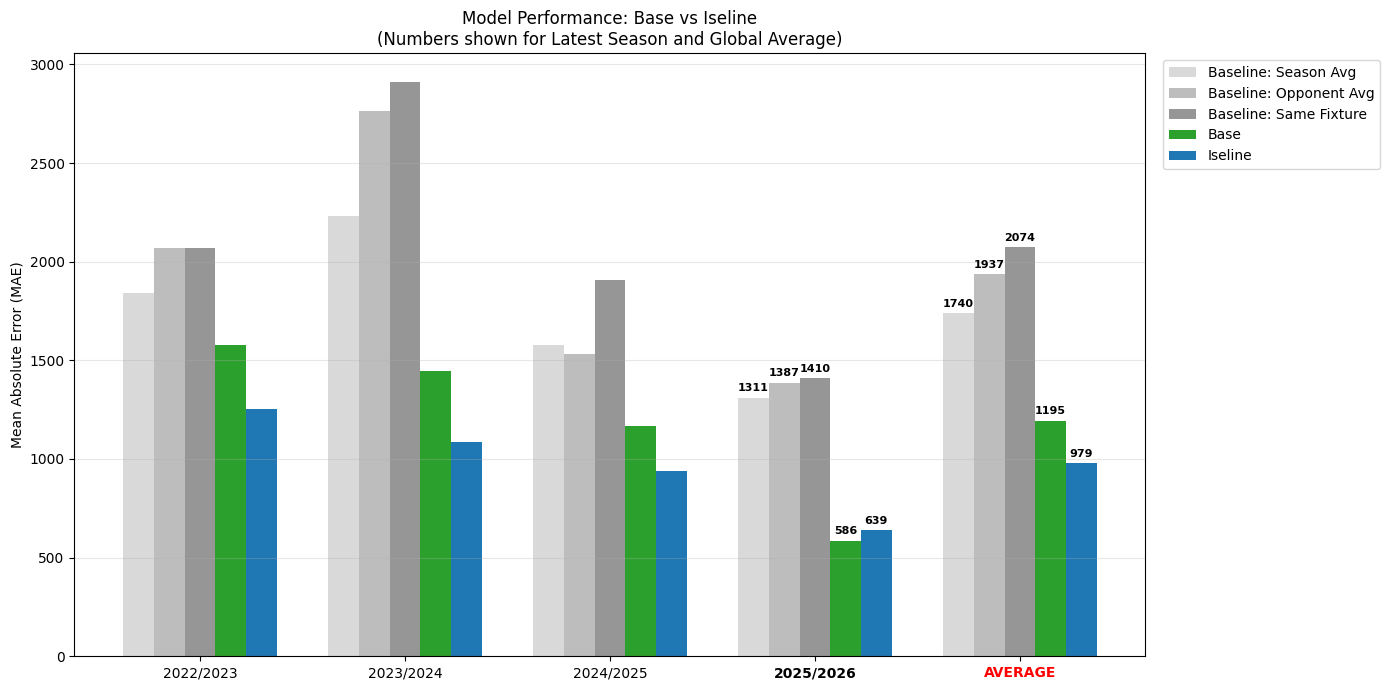

,Baseline: Season Avg,Baseline: Opponent Avg,Baseline: Same Fixture,Base,Iseline
season,,,,,
2022/2023,1841.657912,2067.782090,2067.782090,1579.292559,1252.023419
2023/2024,2230.000110,2761.075188,2911.285714,1447.589942,1084.150278
2024/2025,1576.446507,1531.659357,1908.809357,1165.236752,940.499362
2025/2026,1311.389219,1387.119231,1410.076923,586.409130,638.516805
AVERAGE,1739.873437,1936.908966,2074.488521,1194.632096,978.797466


In [31]:
# List of features in the base model
current_model = [
    "opponent_avg",
    "matchday",
    "is_weekend",
    "academic_week",
    "stage",
    "away_team",
    "rolling_avg_2",
    "season_expanding_avg",
]
current_model_name = "Base"

# List of features in the new model
new_model = [
    "rolling_avg_3",
    "season_expanding_avg",
    "same_fixture_baseline",
    "opponent_avg",
    "matchday",
    "is_weekend",
    "academic_week",
    "points_last_3",
    "form_vs_trend",
    "form_ratio",
    "momentum_2",
    "trib1_div_trend",
    "rolling_avg_2",
    "sold_div_trend"
]
new_model_name = "Iseline"


# Compare the feature sets
compare_feature_sets(
    df=df, 
    features_1=current_model, 
    features_2=new_model, 
    name_1=current_model_name, 
    name_2=new_model_name
)